## Loading and Preprocessing Image

In [5]:
import requests
from PIL import Image
from torchvision import transforms
from torchvision.transforms import functional as F

load image from url and display it

In [2]:
online_img_url = 'https://www.alleycat.org/wp-content/uploads/2019/03/FELV-cat.jpg'
image = Image.open(requests.get(online_img_url, stream=True).raw)

image.show()

create a transform to resize the image to 256x256, convert it to a tensor, and normalize it

In [3]:
transform = transforms.Compose([
    transforms.Resize((256, 256)), # Resize image to 256x256 pixels
    transforms.ToTensor(), # convert into torch Tensors
    transforms.Normalize( # todo: describe normalization
        mean=[0.485, 0.456, 0.406], # -
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = transform(image)
print(img_tensor.size())

torch.Size([3, 256, 256])


## Data Augmentation

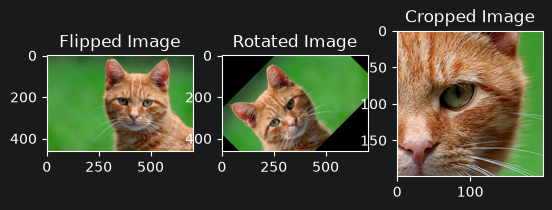

In [6]:
import matplotlib.pyplot as plt

img_flipped = F.hflip(image)
img_rotated = F.rotate(image, angle=45)
img_cropped = F.center_crop(image, (200, 200))

plt.subplot(1, 3, 1)
plt.imshow(img_flipped)
plt.title("Flipped Image")

plt.subplot(1, 3, 2)
plt.imshow(img_rotated)
plt.title("Rotated Image")

plt.subplot(1, 3, 3)
plt.imshow(img_cropped)
plt.title("Cropped Image")

plt.show()